# CAMELS-SIMBA Graph Sanity Checks

This notebook summarizes the first validated preprocessing and graph-construction checks for the thesis project.

The goal is to verify that the CAMELS-SIMBA halo catalogs are converted into scientifically meaningful graphs before scaling to larger datasets and training models.

Current target:

- Cosmological parameter: `Omega_m`

Current graph definition:

- One universe = one sample
- One snapshot = one graph
- Nodes = halos
- Node features = `[log10(Mvir), X, Y, Z, VX, VY, VZ]`
- Edges = periodic boundary-aware k-nearest-neighbor graph from raw physical positions
- Temporal sample = sequence of 5 snapshot graphs

In [3]:
from pathlib import Path
from IPython.display import Image, display, HTML
import pandas as pd
import json
import os
import sys

# ============================================================
# Robust project-root detection
# ============================================================
# This notebook is stored inside:
#   notebooks/visualization/
#
# All project paths are resolved from the repository root discovered below.
#
# So we search upward until we find the folder containing:
#   src/
#   data/
#   outputs/
# ============================================================

current = Path.cwd().resolve()

PROJECT_ROOT = None

for candidate in [current, *current.parents]:
    if (
        (candidate / "src").exists()
        and (candidate / "data").exists()
        and (candidate / "outputs").exists()
    ):
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError(
        "Could not find project root. "
        "Expected a parent folder containing src/, data/, and outputs/."
    )

os.chdir(PROJECT_ROOT)

# Make sure Python can import from src/
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Current working directory:")
print(Path.cwd())

print("\nProject root exists:", PROJECT_ROOT.exists())
print("Outputs folder exists:", Path("outputs").exists())
print("Data folder exists:", Path("data").exists())
print("Source folder exists:", Path("src").exists())

print("\nNotebook setup complete.")

Current working directory:
<REPO_ROOT>

Project root exists: True
Outputs folder exists: True
Data folder exists: True
Source folder exists: True

Notebook setup complete.


## 1. Official Preprocessing Configuration

The current official preprocessing version is:

`v2_logmass_minmax_top100_periodic_knn`

The key scientific choices are:

1. Select the top 100 halos using raw `Mvir`.
2. Transform halo mass into `log10(Mvir)` for the node feature matrix.
3. Use raw physical positions `X, Y, Z` to build graph edges.
4. Use periodic boundary-aware kNN because CAMELS simulation boxes are periodic.
5. Normalize node features using minmax normalization for stable machine learning.

In [4]:
preprocessing_config = {
    "preprocessing_version": "v2_logmass_minmax_top100_periodic_knn",
    "dataset": "CAMELS-SIMBA",
    "target": "Omega_m",
    "node_selection": "Top 100 halos by raw Mvir",
    "node_features": ["log10_Mvir", "X", "Y", "Z", "VX", "VY", "VZ"],
    "normalization": "minmax",
    "graph_construction": "kNN from raw physical X/Y/Z positions",
    "k": 8,
    "periodic_boundary": True,
    "box_size": 25.0,
    "temporal_snapshots": 5,
}

preprocessing_config

{'preprocessing_version': 'v2_logmass_minmax_top100_periodic_knn',
 'dataset': 'CAMELS-SIMBA',
 'target': 'Omega_m',
 'node_selection': 'Top 100 halos by raw Mvir',
 'node_features': ['log10_Mvir', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ'],
 'normalization': 'minmax',
 'graph_construction': 'kNN from raw physical X/Y/Z positions',
 'k': 8,
 'periodic_boundary': True,
 'box_size': 25.0,
 'temporal_snapshots': 5}

## 2. Target Inspection

Before building datasets, the raw CAMELS-SIMBA files were inspected to extract the real `Omega_m` value from the file metadata.

This check confirms that the model will use real cosmological targets rather than dummy labels.

In [5]:
target_csv = Path("outputs/target_inspection_20u.csv")
target_json = Path("outputs/target_inspection_20u.json")

print("Target CSV exists:", target_csv.exists())
print("Target JSON exists:", target_json.exists())

targets = pd.read_csv(target_csv)
targets.head(20)

Target CSV exists: True
Target JSON exists: True


,universe_id,universe_index,omega_m,num_files,required_snapshots,enough_snapshots,snapshots,first_snapshot,last_snapshot,target_key,target_consistent,missing_target,target_in_expected_range,num_unique_targets_found,unique_targets_found,status,example_file,preprocessing_version_context,camels_box_size_context
0,LH_0,0,0.1462,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.1462,OK,LH_0_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
1,LH_1,1,0.1198,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.1198,OK,LH_1_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
2,LH_2,2,0.4226,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.4226,OK,LH_2_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
3,LH_3,3,0.2398,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.2398,OK,LH_3_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
4,LH_4,4,0.3742,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.3742,OK,LH_4_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
5,LH_5,5,0.1174,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.1174,OK,LH_5_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
6,LH_6,6,0.1202,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.1202,OK,LH_6_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
7,LH_7,7,0.3438,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.3438,OK,LH_7_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
8,LH_8,8,0.4018,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.4018,OK,LH_8_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0
9,LH_9,9,0.2062,5,5,True,"0.2,0.25,0.51209,0.75065,1.0",0.2,1.0,Omega_M,True,False,True,1,0.2062,OK,LH_9_hlist_1.00000.list,v2_logmass_minmax_top100_periodic_knn,25.0


## 3. One-Graph Visual Diagnostics

A single final-snapshot halo graph was generated for `LH_0` at snapshot scale factor `a = 1.0`.

This graph is used as a sanity check before building large temporal datasets.

In [6]:
BASE = Path("outputs/graph_diagnostics/v2_logmass_minmax_top100_periodic_knn")

periodic_on_dir = BASE / "LH_0_snapshot_1.00000"
periodic_on_alt = BASE / "LH_0_snapshot_1.00000_periodic_on"

# Use whichever folder exists.
if periodic_on_alt.exists():
    periodic_on_dir = periodic_on_alt

periodic_off_dir = BASE / "LH_0_snapshot_1.00000_periodic_off"

print("Periodic ON folder:", periodic_on_dir)
print("Exists:", periodic_on_dir.exists())

print("\nPeriodic OFF folder:", periodic_off_dir)
print("Exists:", periodic_off_dir.exists())

print("\nFiles in periodic ON folder:")
for p in sorted(periodic_on_dir.glob("*")):
    print("-", p.name)

Periodic ON folder: outputs/graph_diagnostics/v2_logmass_minmax_top100_periodic_knn/LH_0_snapshot_1.00000_periodic_on
Exists: True

Periodic OFF folder: outputs/graph_diagnostics/v2_logmass_minmax_top100_periodic_knn/LH_0_snapshot_1.00000_periodic_off
Exists: True

Files in periodic ON folder:
- 01_graph_3d_static.png
- 02_graph_3d_interactive.html
- 03_degree_distribution.png
- 05_graph_visual_summary.json
- 06_xy_projection.png
- 07_xz_projection.png
- 08_yz_projection.png
- 09_log10_mass_histogram.png
- 11_edge_distance_distribution.png
- 12_adjacency_matrix.png


## 4. Static 3D Graph

This plot shows the selected top-100 halos in 3D physical space.

Nodes are colored by `log10(Mvir)`.  
Edges are built using periodic boundary-aware kNN with `k = 8`.

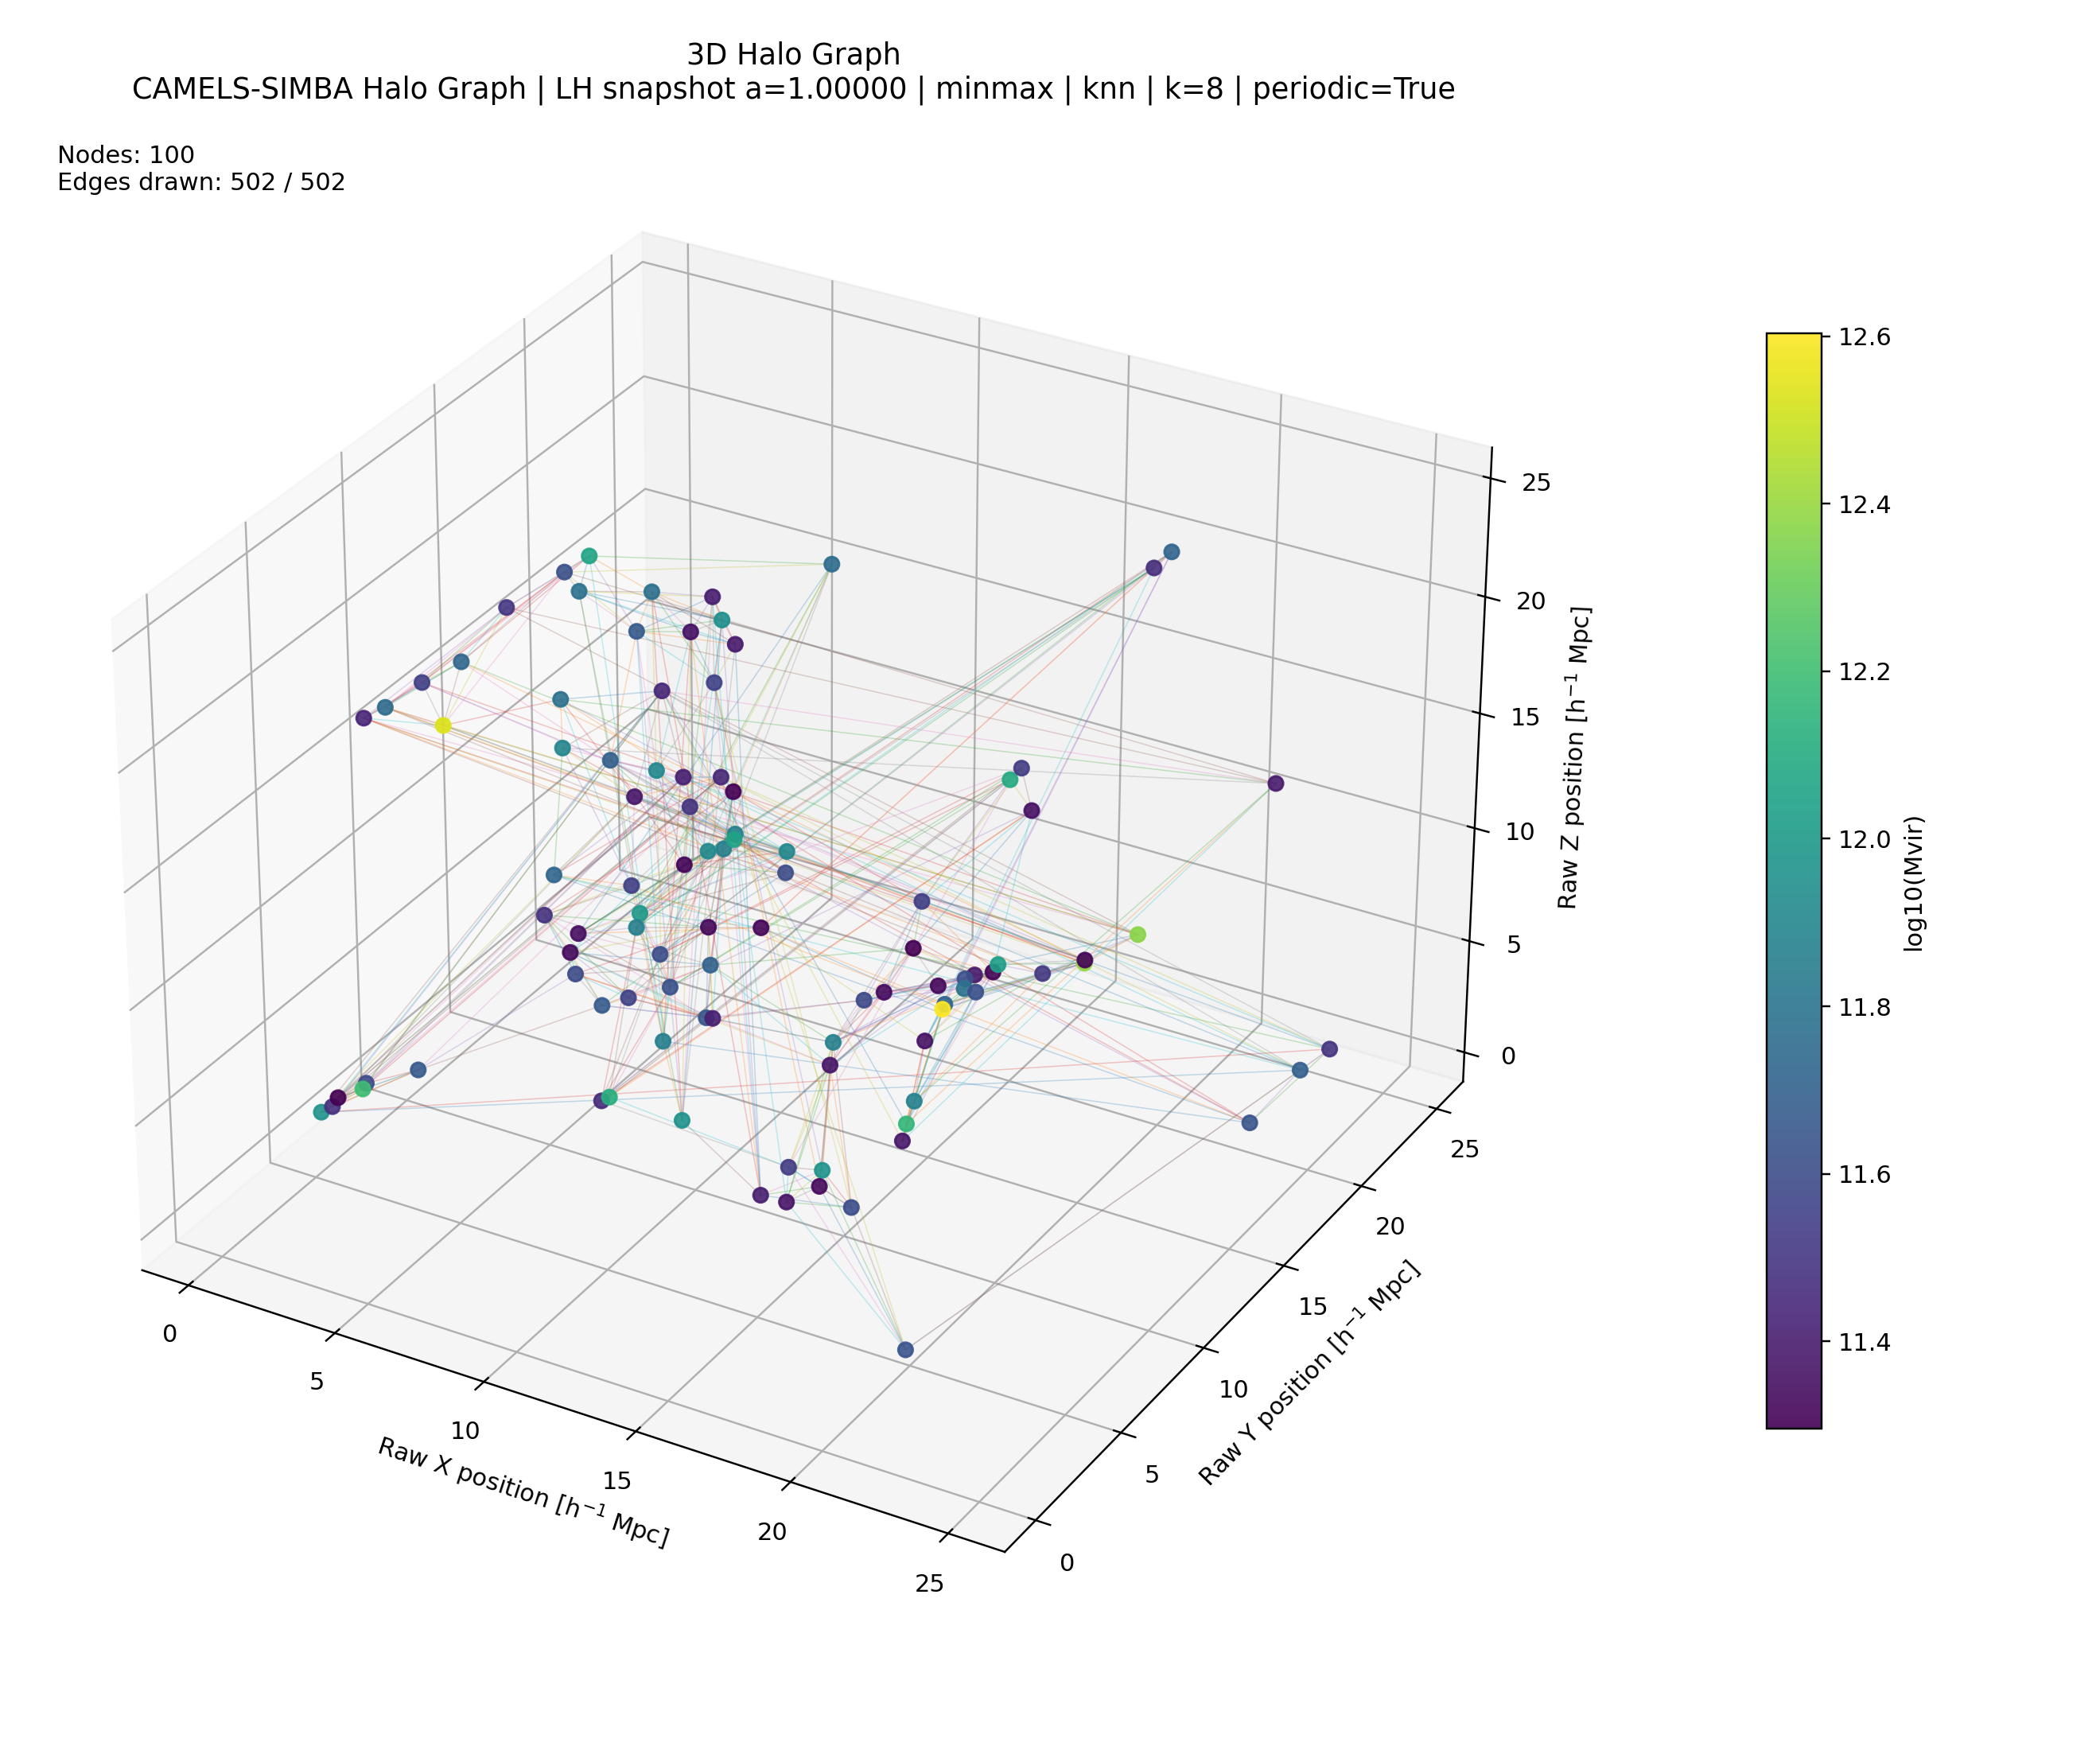

In [7]:
display(Image(filename=str(periodic_on_dir / "01_graph_3d_static.png")))

## 5. Interactive 3D Graph

The interactive HTML plot allows rotation, zooming, and manual inspection of the halo graph.

This is useful because the graph can be explored visually instead of only shown as a static image.

In [8]:
interactive_path = periodic_on_dir / "02_graph_3d_interactive.html"

print("Interactive file exists:", interactive_path.exists())
print("Path:", interactive_path)

HTML(filename=str(interactive_path))

Interactive file exists: True
Path: outputs/graph_diagnostics/v2_logmass_minmax_top100_periodic_knn/LH_0_snapshot_1.00000_periodic_on/02_graph_3d_interactive.html


## 6. Degree Distribution

The graph uses kNN with `k = 8`.

Because the graph is symmetrized, the minimum degree is usually 8, while some nodes have higher degree because they are selected as neighbors by other halos.

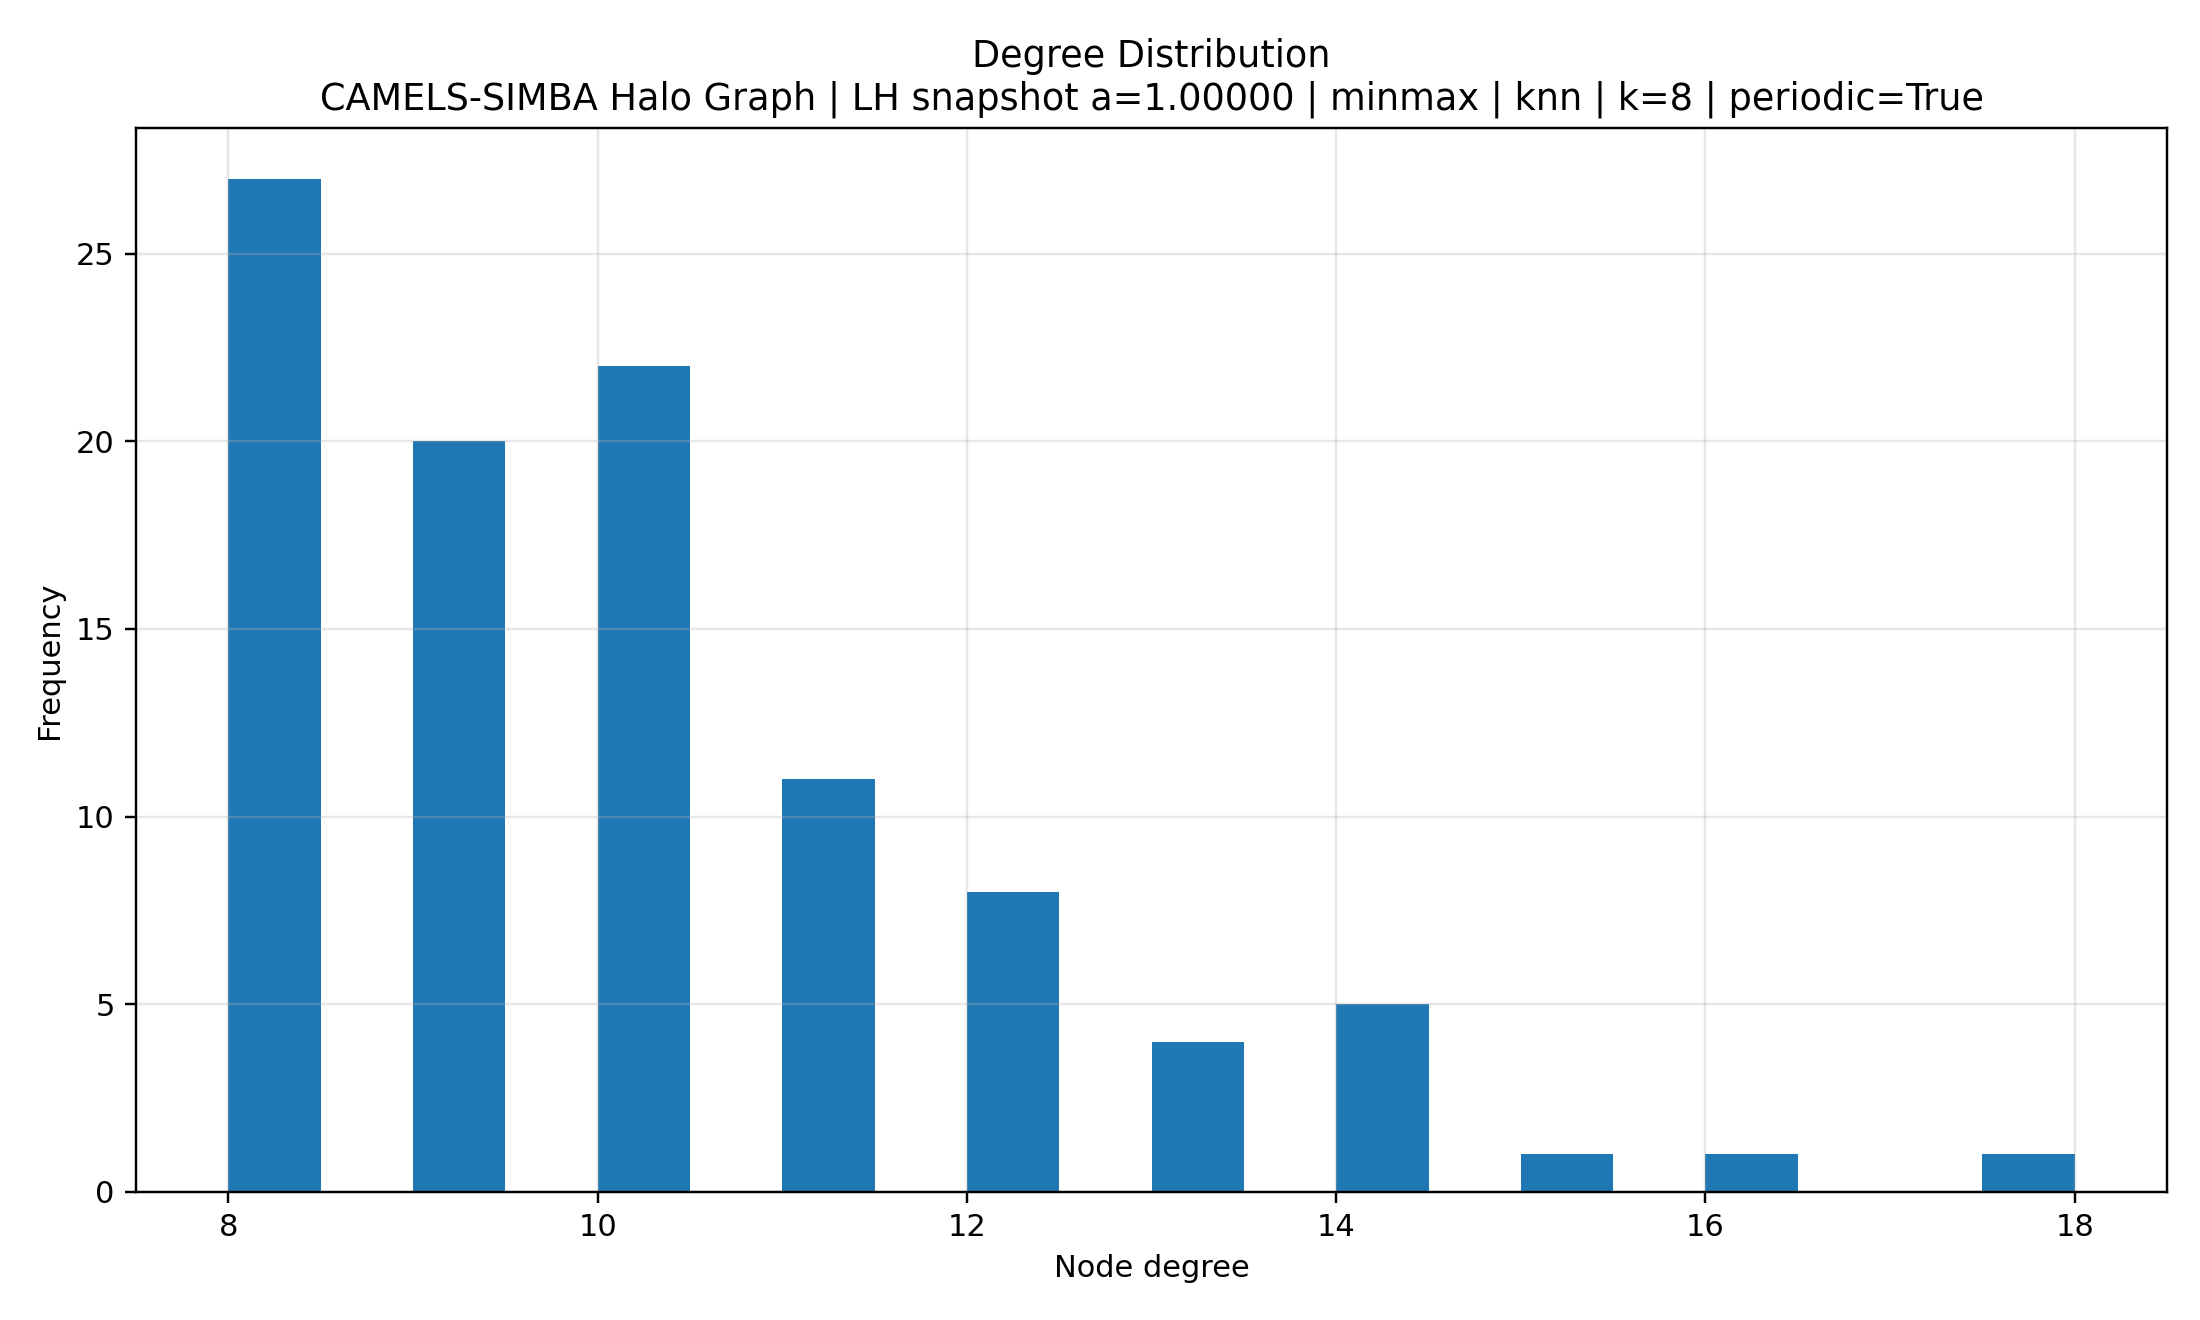

In [9]:
display(Image(filename=str(periodic_on_dir / "03_degree_distribution.png")))

## 7. 2D Position Projections

The XY, XZ, and YZ projections help verify that halo positions are distributed inside the CAMELS simulation box.

The expected box range is approximately:

`0 <= X, Y, Z <= 25`

06_xy_projection.png


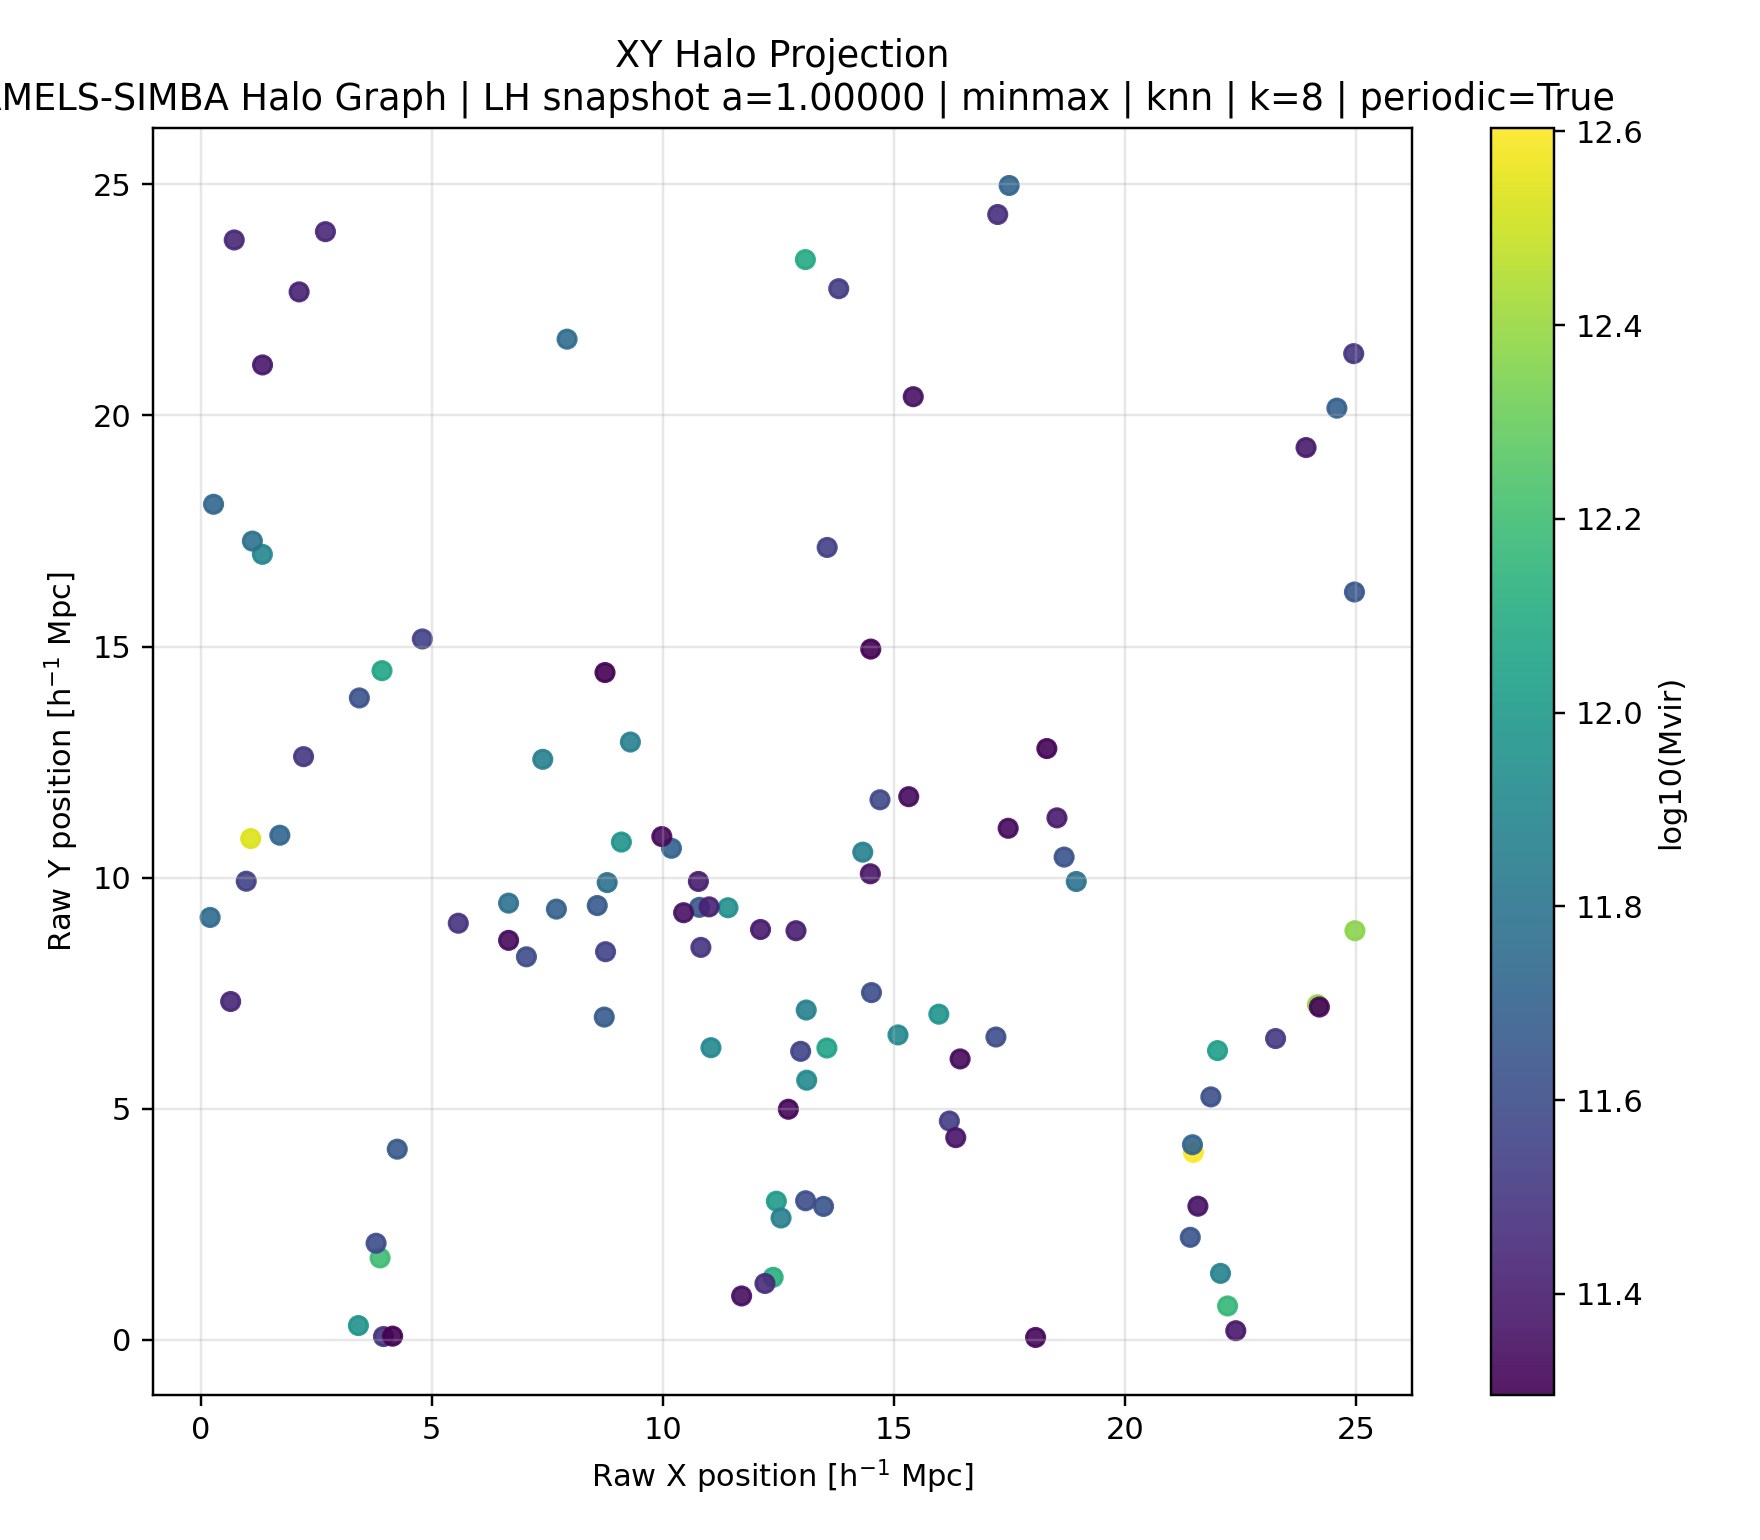

07_xz_projection.png


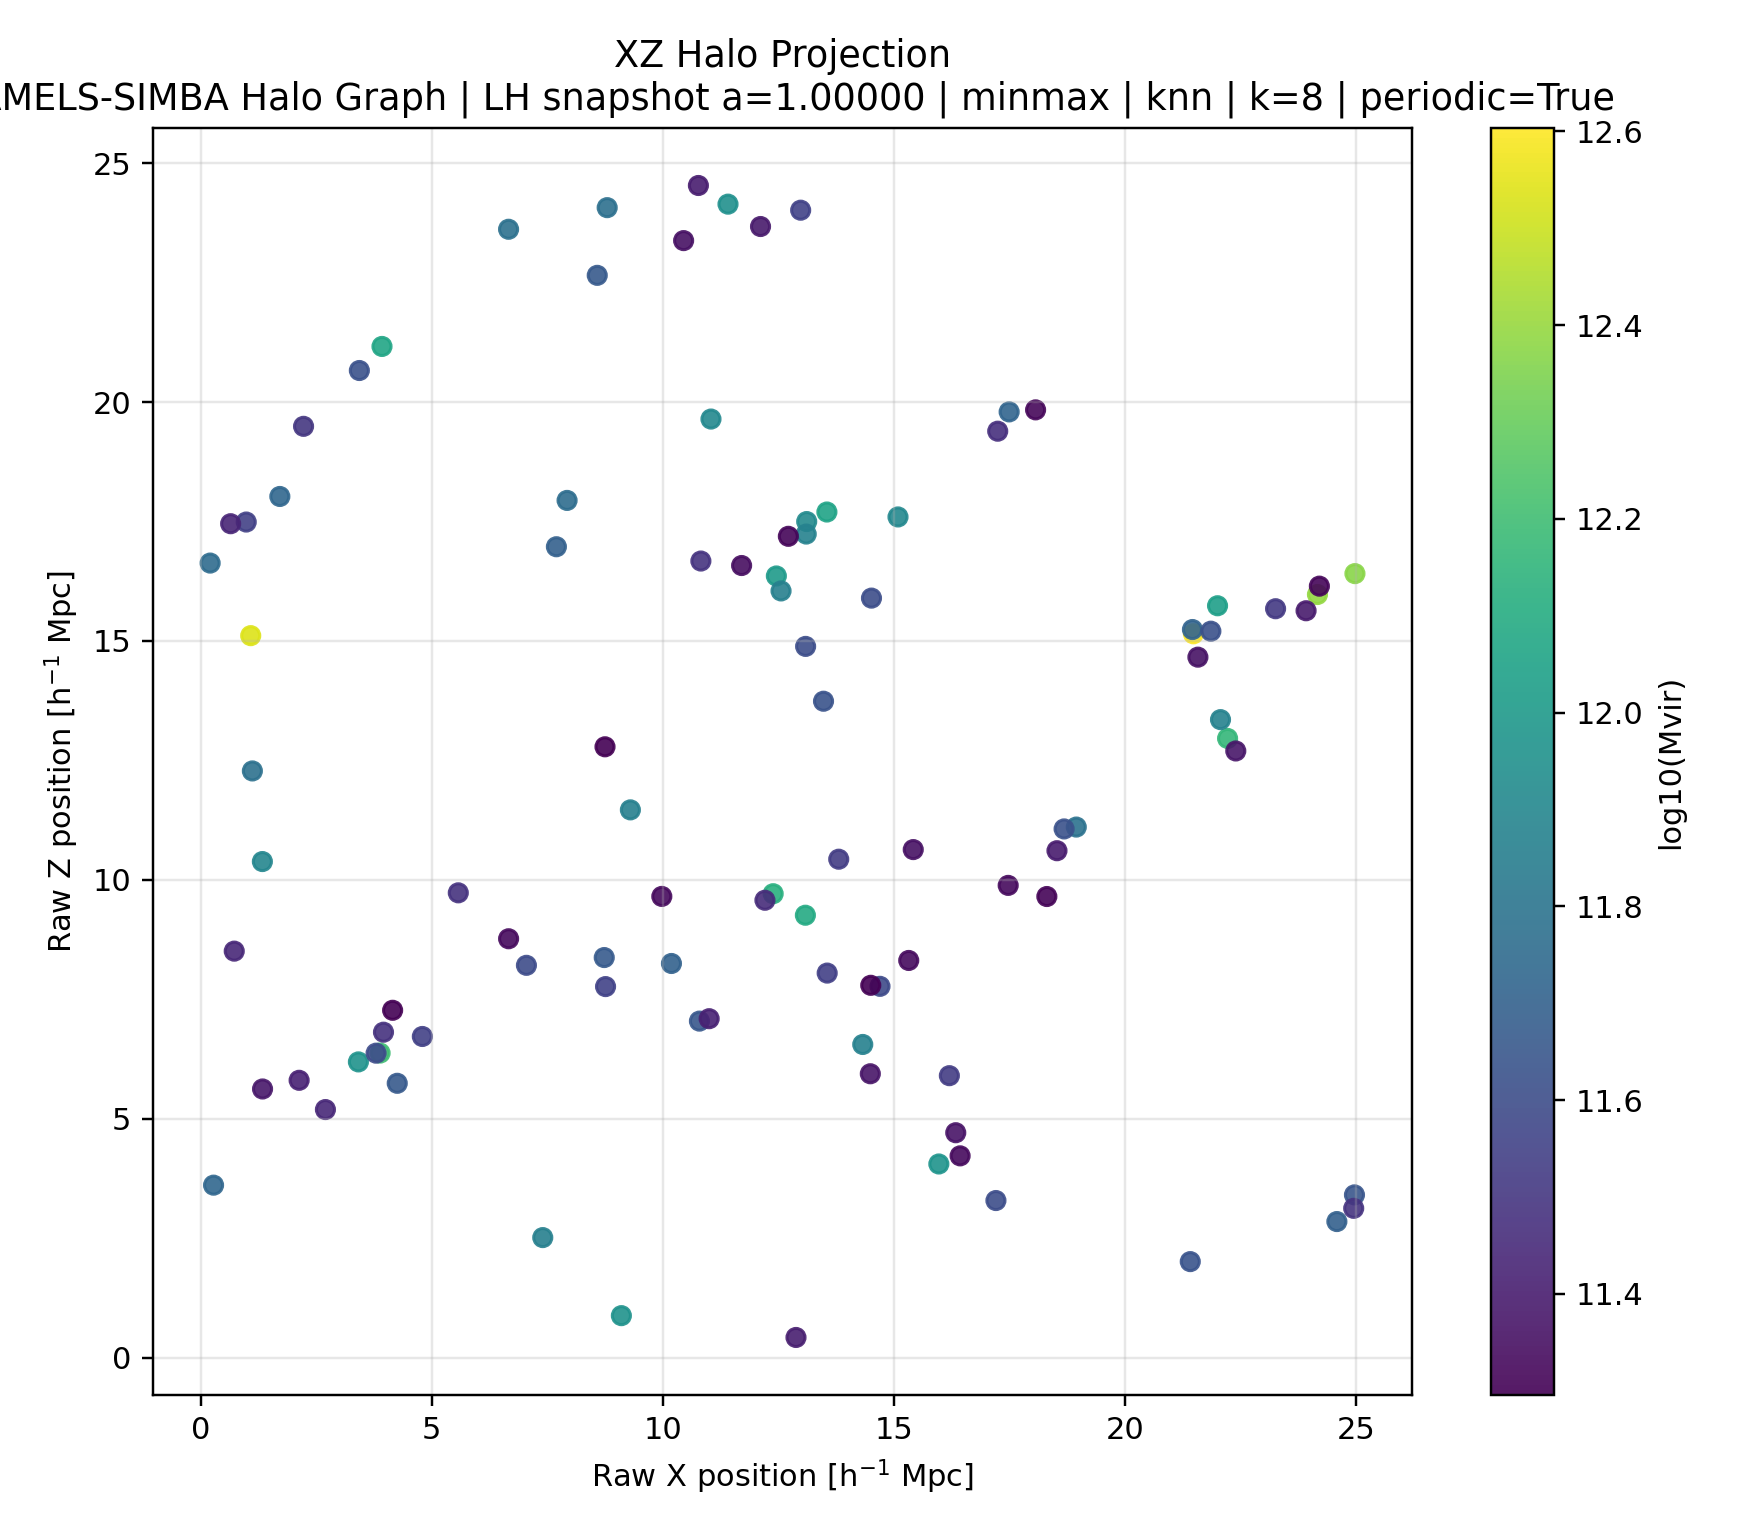

08_yz_projection.png


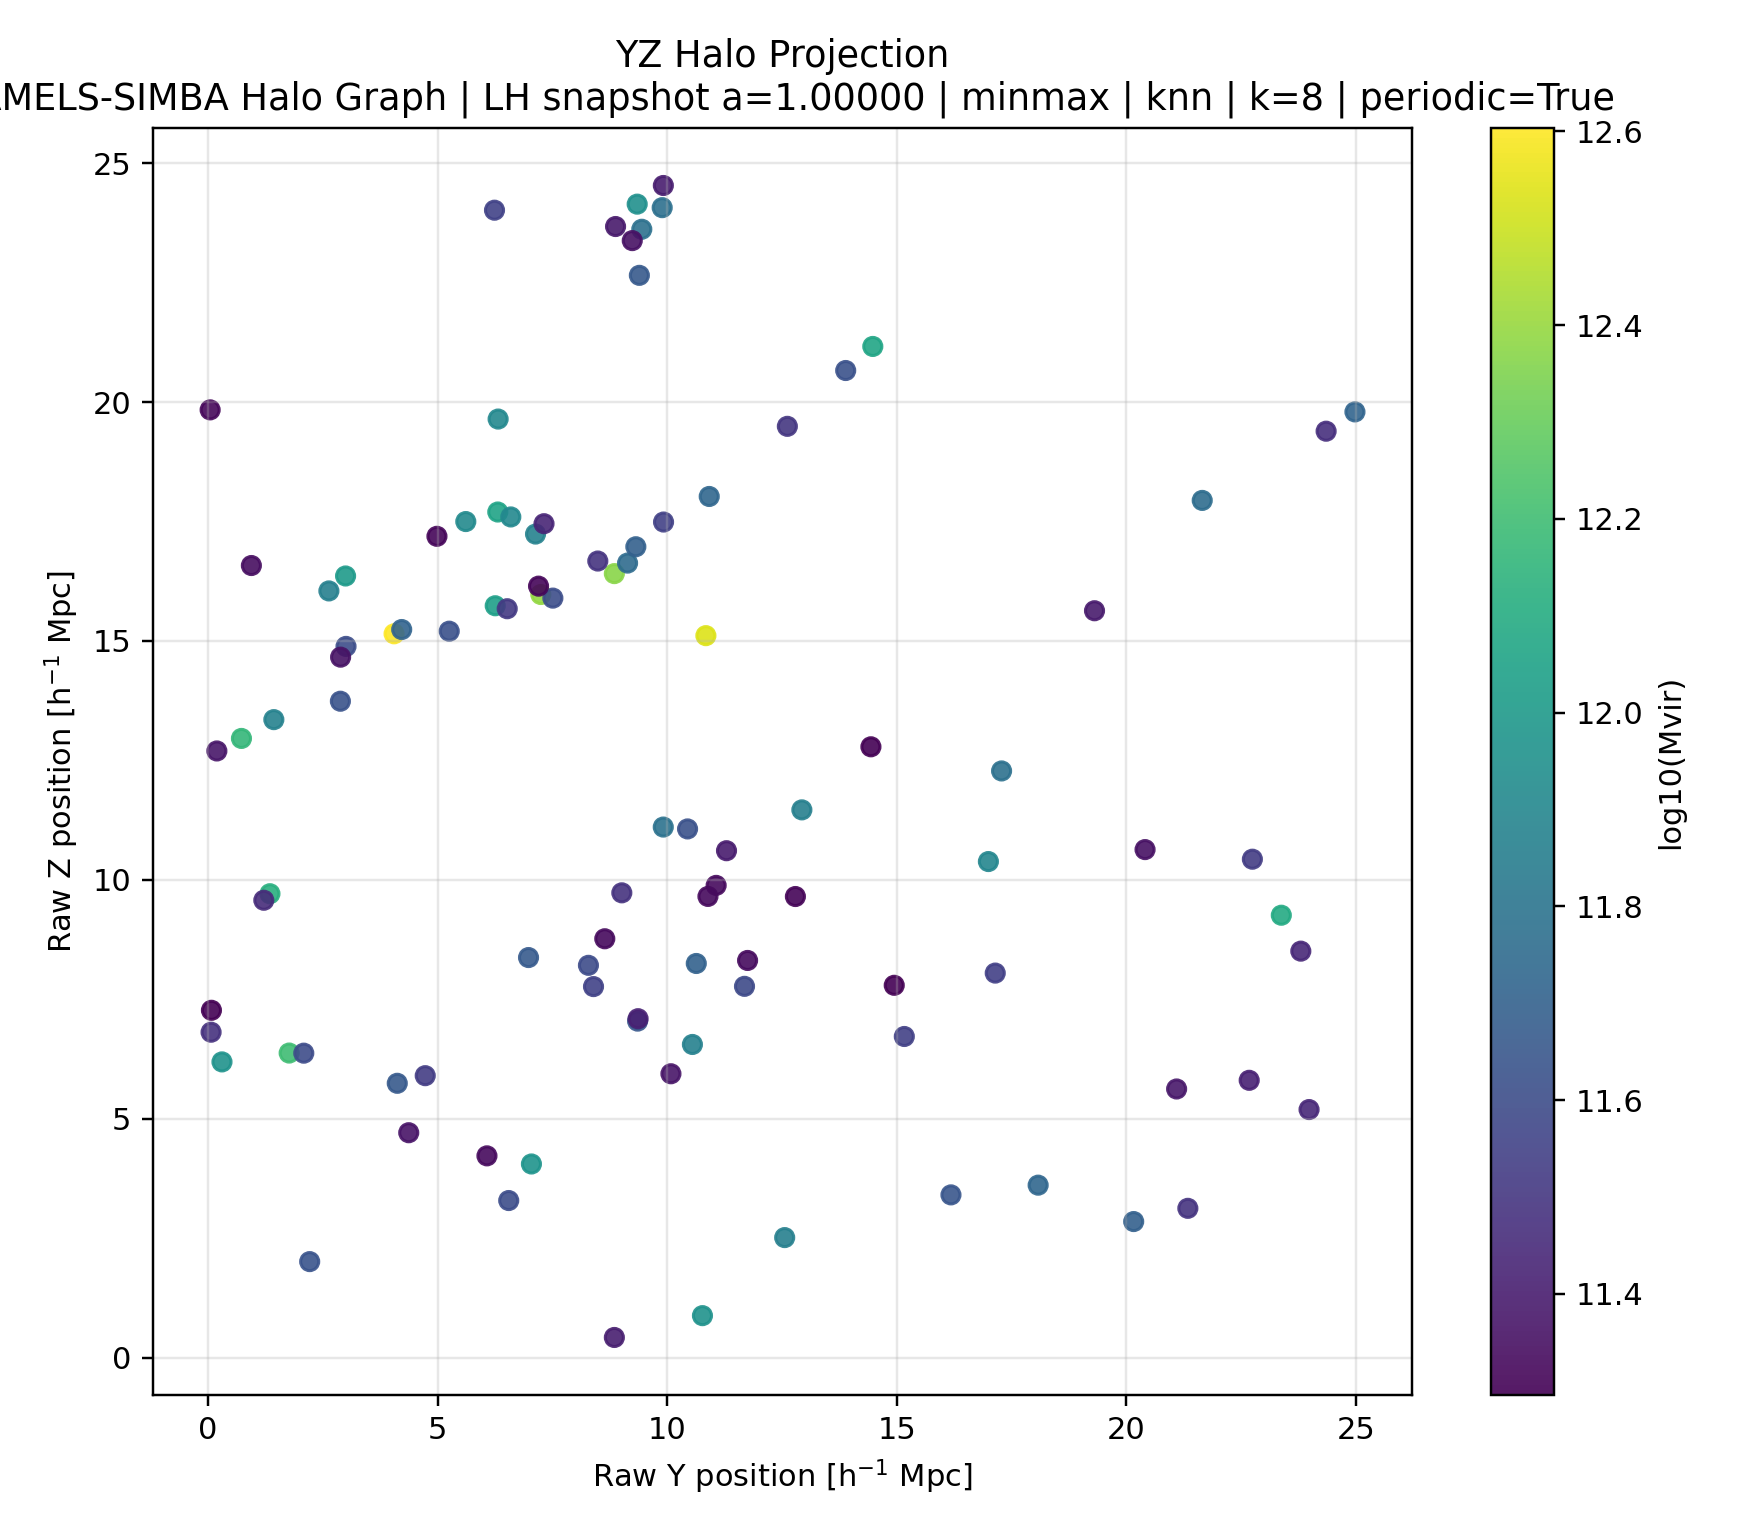

In [10]:
projection_files = [
    "06_xy_projection.png",
    "07_xz_projection.png",
    "08_yz_projection.png",
]

for file in projection_files:
    print(file)
    display(Image(filename=str(periodic_on_dir / file)))

## 8. log10(Mvir) Distribution

The selected halos are the top 100 halos by raw `Mvir`.

For machine learning, raw mass is transformed into `log10(Mvir)` because halo mass spans a large numerical range.

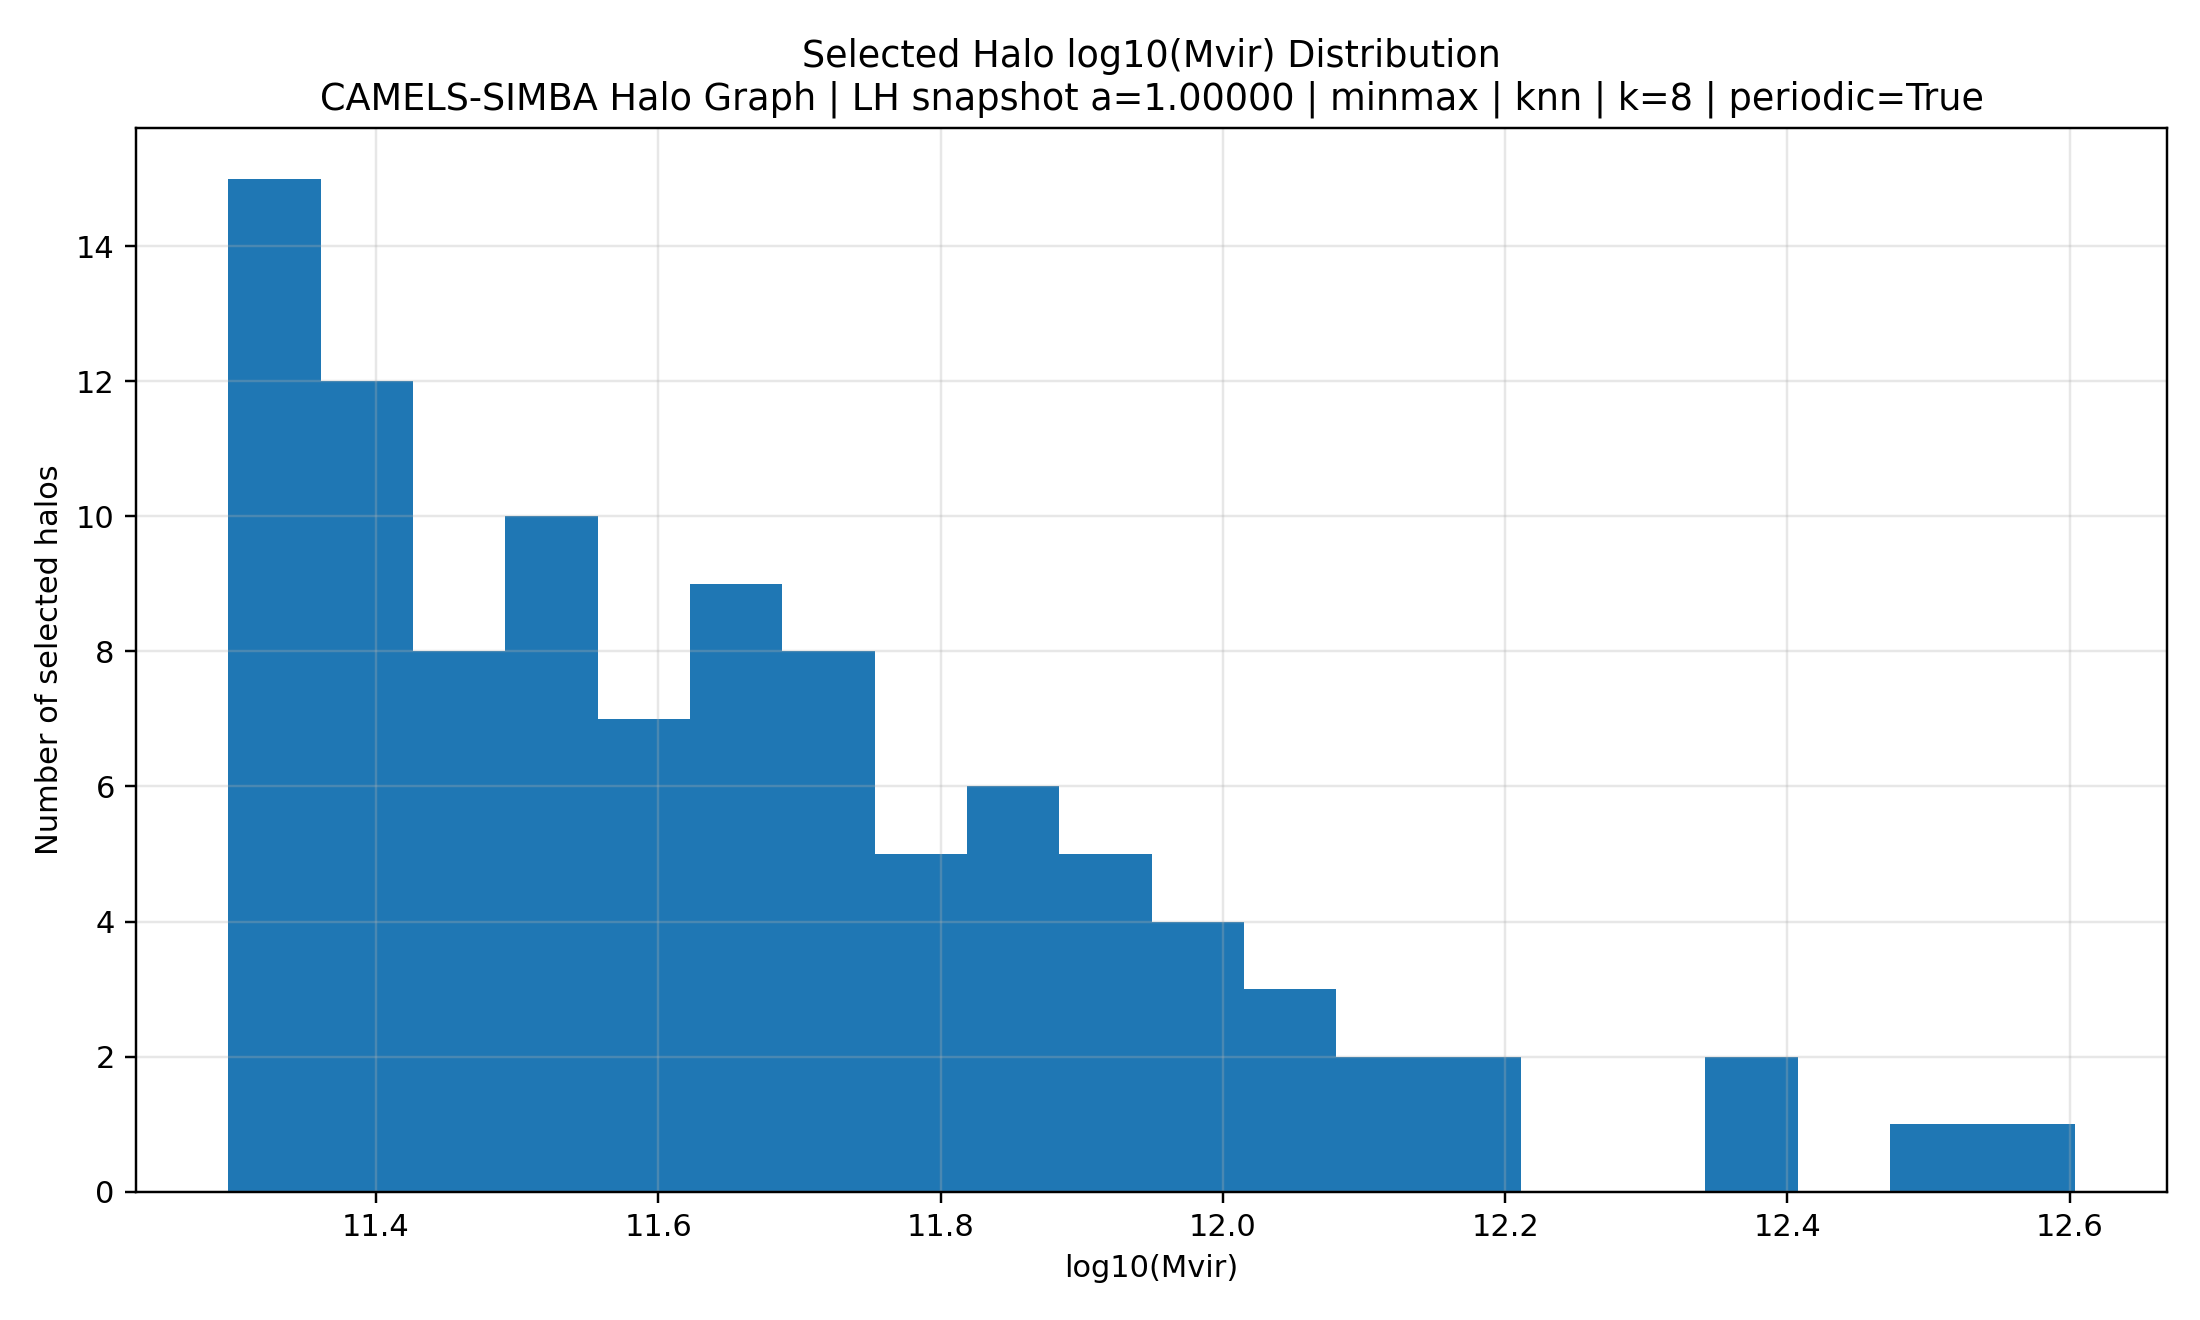

In [11]:
display(Image(filename=str(periodic_on_dir / "09_log10_mass_histogram.png")))

## 9. Edge-Distance Distribution

This plot shows the physical distance distribution of graph edges.

For the periodic version, distances are computed using the minimum-image convention, which is appropriate for periodic simulation boxes.

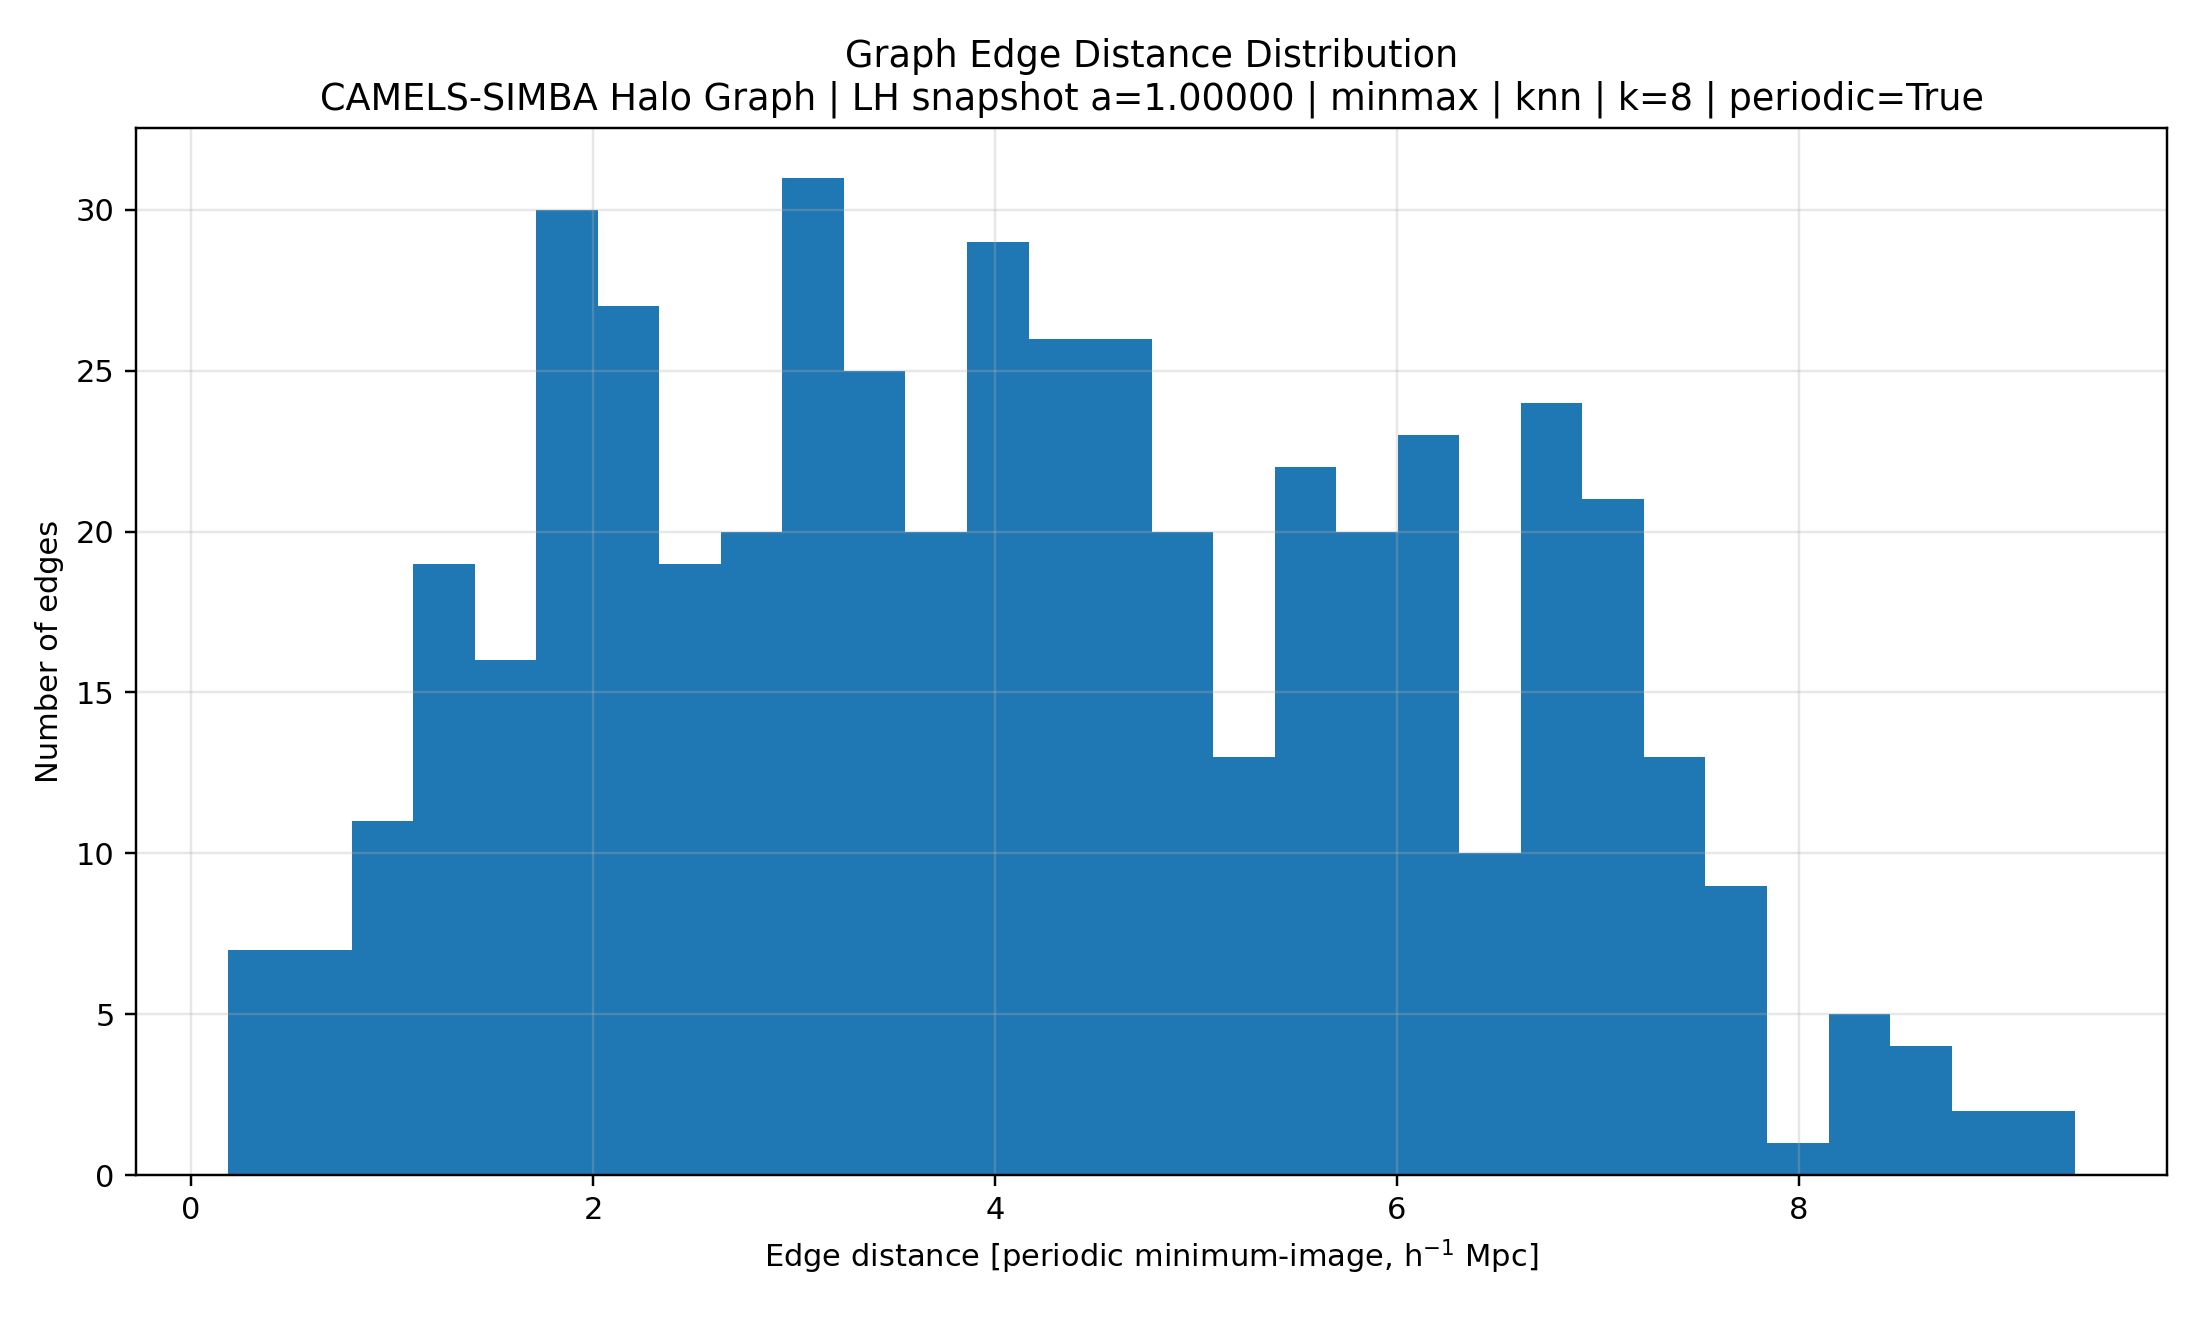

In [12]:
display(Image(filename=str(periodic_on_dir / "11_edge_distance_distribution.png")))

## 10. Adjacency Matrix

The adjacency matrix shows which halos are connected.

A symmetric matrix confirms that the graph is treated as an undirected graph.

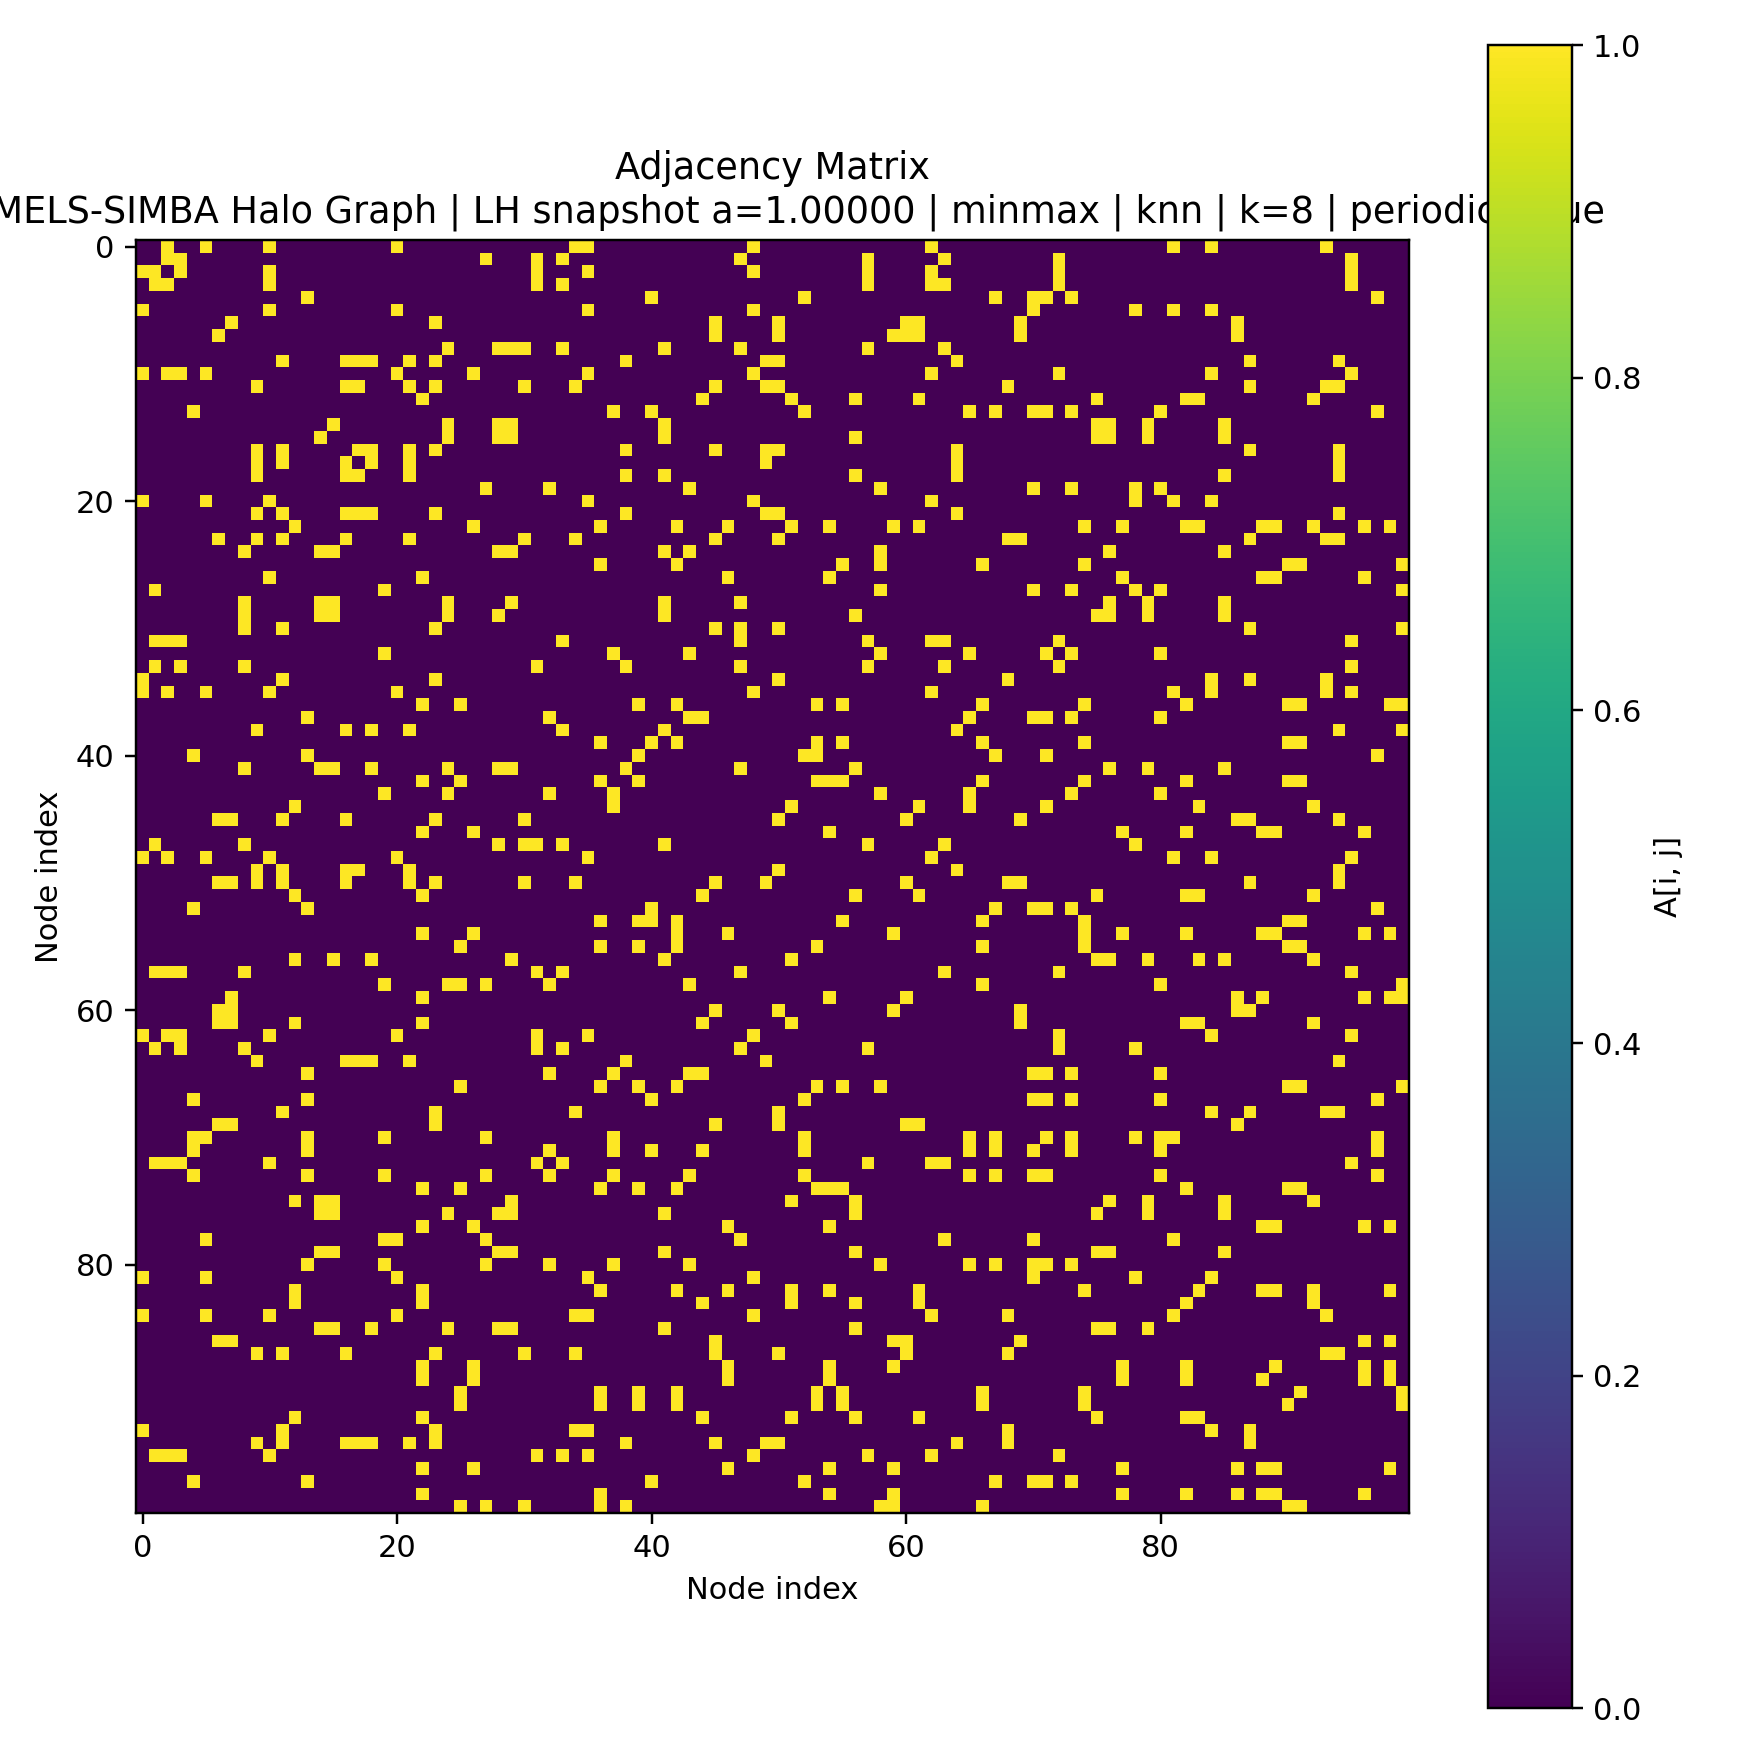

In [13]:
display(Image(filename=str(periodic_on_dir / "12_adjacency_matrix.png")))

## 11. Periodic vs Non-Periodic kNN Comparison

To verify that periodic boundary handling changes the graph construction correctly, the same snapshot was processed twice:

1. Periodic boundary-aware kNN enabled.
2. Ordinary Euclidean kNN without periodic boundaries.

This comparison checks whether the graph construction responds to the CAMELS periodic box geometry.

Periodic ON edge-distance distribution


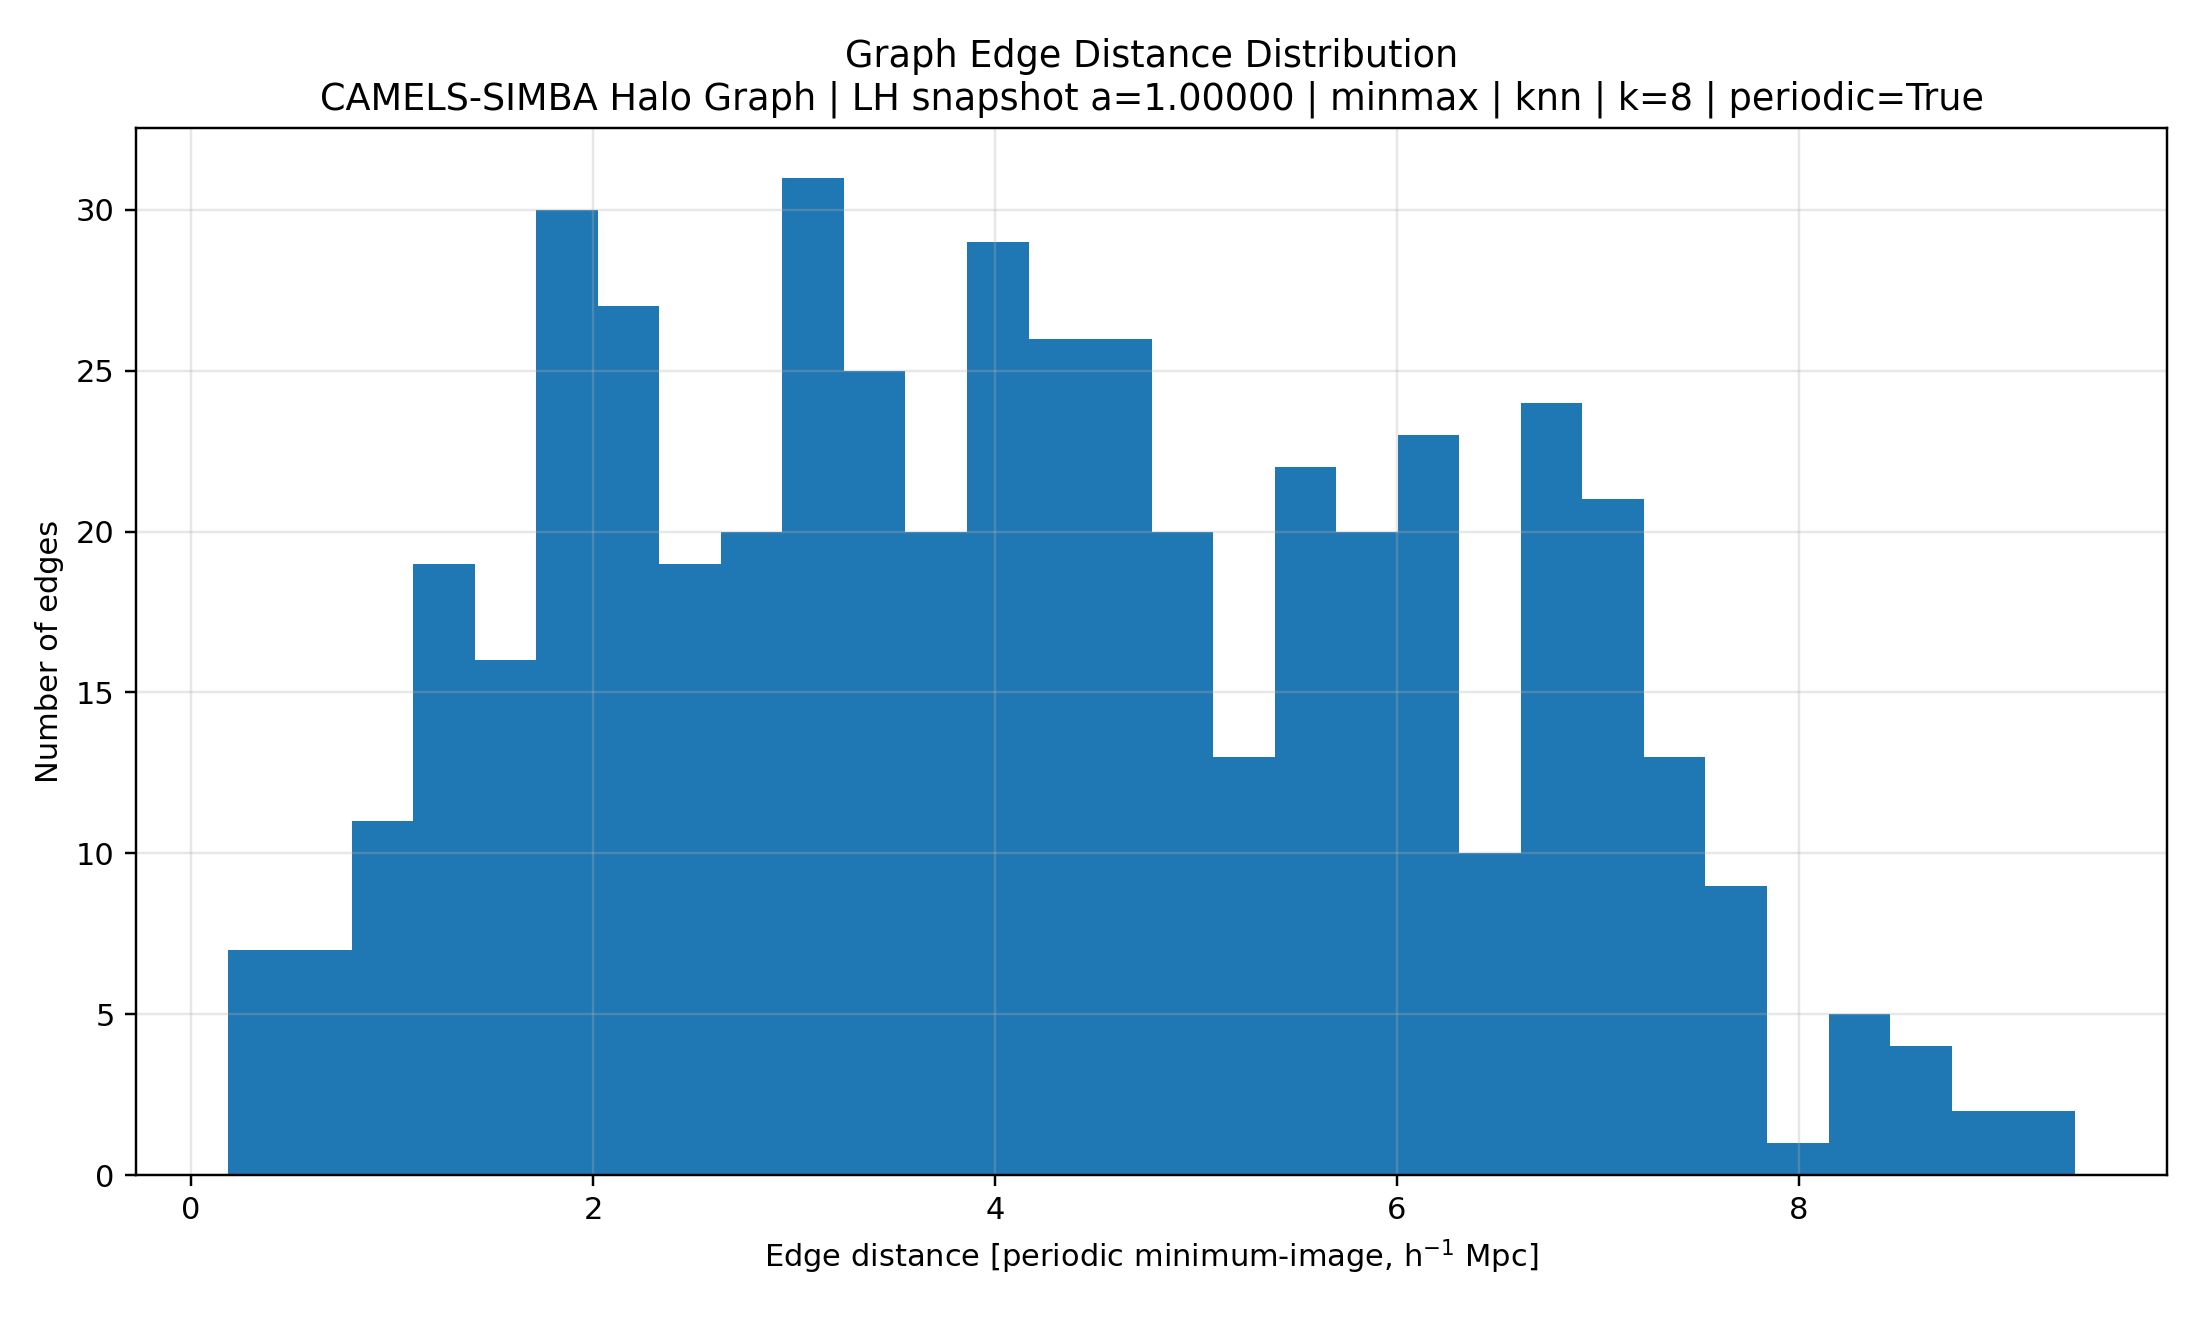

Periodic OFF edge-distance distribution


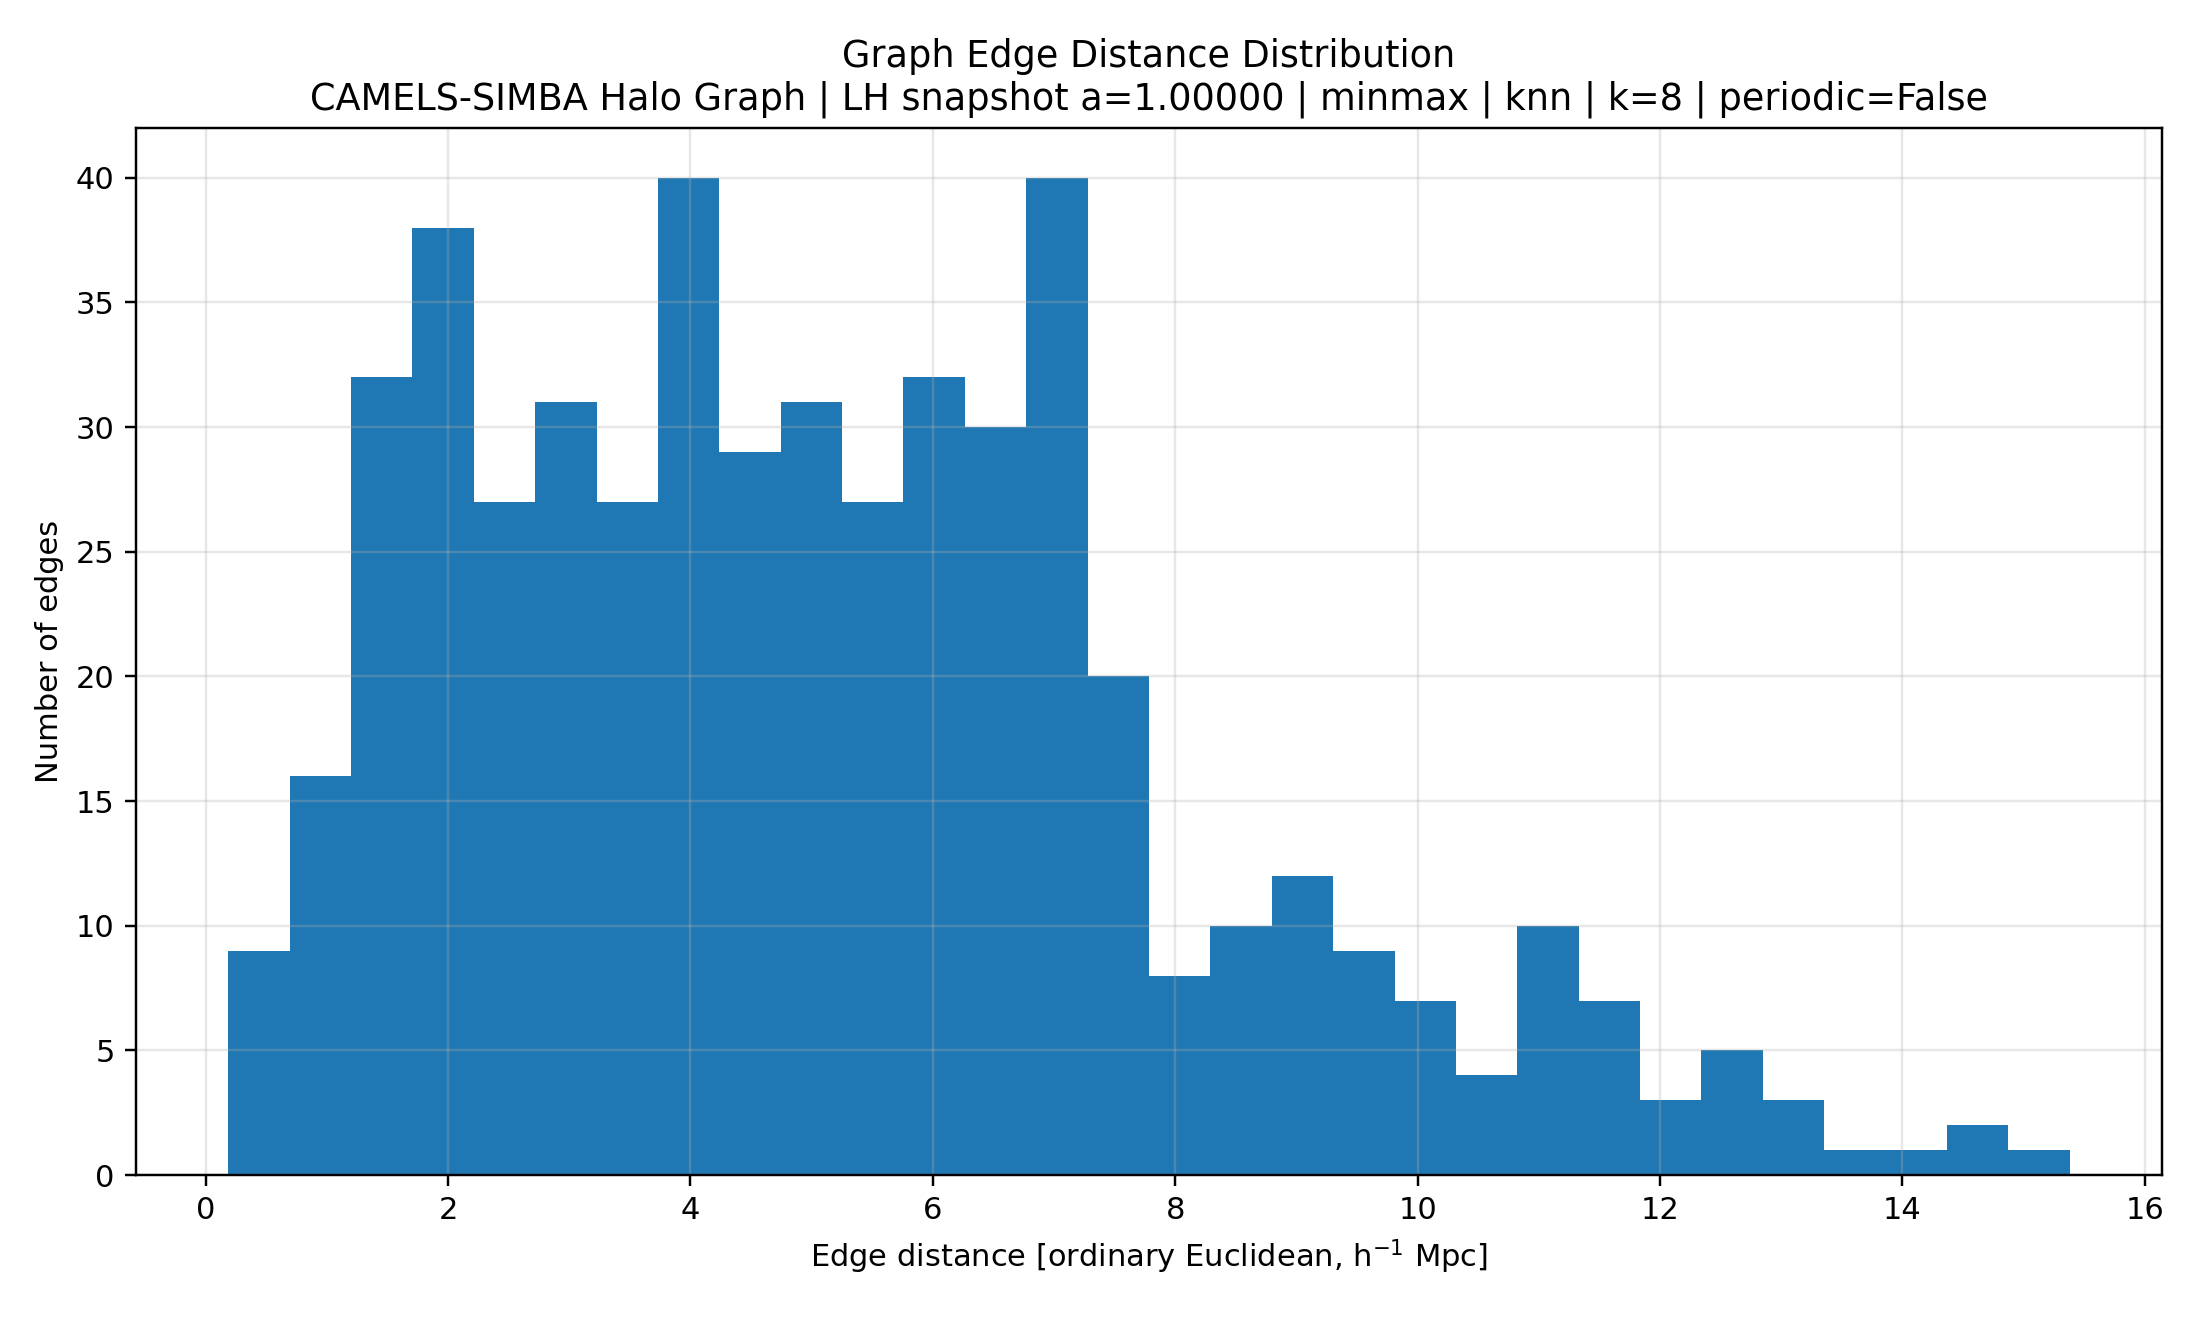

In [14]:
if periodic_off_dir.exists():
    print("Periodic ON edge-distance distribution")
    display(Image(filename=str(periodic_on_dir / "11_edge_distance_distribution.png")))

    print("Periodic OFF edge-distance distribution")
    display(Image(filename=str(periodic_off_dir / "11_edge_distance_distribution.png")))
else:
    print("Periodic OFF folder not found.")

## 11.1 Quantitative Periodic Boundary Comparison

This table compares graph statistics between periodic boundary-aware kNN and ordinary Euclidean kNN.
The goal is to confirm that periodic boundary handling affects the graph in a physically meaningful way.

In [18]:
import json
import pandas as pd
from pathlib import Path

def load_json_if_exists(path: Path):
    if path.exists():
        with open(path, "r", encoding="utf-8") as f:
            return json.load(f)
    return None


def get_first_available(summary: dict, possible_keys: list):
    """
    Return the first available value from a list of possible JSON keys.
    This makes the notebook robust even if the JSON uses slightly different names.
    """
    if summary is None:
        return None

    for key in possible_keys:
        if key in summary:
            return summary.get(key)

    return None


on_summary_path = periodic_on_dir / "05_graph_visual_summary.json"
off_summary_path = periodic_off_dir / "05_graph_visual_summary.json"

print("Periodic ON summary path:")
print(on_summary_path)
print("Exists:", on_summary_path.exists())

print("\nPeriodic OFF summary path:")
print(off_summary_path)
print("Exists:", off_summary_path.exists())

on_summary = load_json_if_exists(on_summary_path)
off_summary = load_json_if_exists(off_summary_path)

if on_summary is not None:
    print("\nPeriodic ON summary keys:")
    print(list(on_summary.keys()))
else:
    print("\n❌ Periodic ON summary is missing.")

if off_summary is not None:
    print("\nPeriodic OFF summary keys:")
    print(list(off_summary.keys()))
else:
    print("\n❌ Periodic OFF summary is missing.")


if on_summary is not None and off_summary is not None:
    comparison = {
        "periodic_on_edges": get_first_available(
            on_summary,
            ["num_edges", "undirected_edges", "num_undirected_edges", "edge_count", "valid_edges"]
        ),
        "periodic_off_edges": get_first_available(
            off_summary,
            ["num_edges", "undirected_edges", "num_undirected_edges", "edge_count", "valid_edges"]
        ),
        "periodic_on_degree_mean": get_first_available(
            on_summary,
            ["degree_mean", "valid_degree_mean", "mean_degree"]
        ),
        "periodic_off_degree_mean": get_first_available(
            off_summary,
            ["degree_mean", "valid_degree_mean", "mean_degree"]
        ),
        "periodic_on_distance_mean": get_first_available(
            on_summary,
            ["edge_distance_mean", "distance_mean", "mean_edge_distance"]
        ),
        "periodic_off_distance_mean": get_first_available(
            off_summary,
            ["edge_distance_mean", "distance_mean", "mean_edge_distance"]
        ),
        "periodic_on_distance_max": get_first_available(
            on_summary,
            ["edge_distance_max", "distance_max", "max_edge_distance"]
        ),
        "periodic_off_distance_max": get_first_available(
            off_summary,
            ["edge_distance_max", "distance_max", "max_edge_distance"]
        ),
    }

    comparison_df = pd.DataFrame([comparison])
    display(comparison_df)

    print("\nInterpretation:")
    print(
        "The periodic boundary-aware graph should usually have shorter or more physically "
        "reasonable edge distances than the non-periodic graph, because CAMELS simulation "
        "boxes wrap around at the boundaries."
    )

else:
    print("\nCannot build comparison table because one of the summary JSON files is missing.")

Periodic ON summary path:
outputs/graph_diagnostics/v2_logmass_minmax_top100_periodic_knn/LH_0_snapshot_1.00000_periodic_on/05_graph_visual_summary.json
Exists: True

Periodic OFF summary path:
outputs/graph_diagnostics/v2_logmass_minmax_top100_periodic_knn/LH_0_snapshot_1.00000_periodic_off/05_graph_visual_summary.json
Exists: True

Periodic ON summary keys:
['preprocessing_version', 'expected_preprocessing_version', 'snapshot_path', 'snapshot_value', 'feature_names', 'feature_columns', 'mass_column', 'mass_feature', 'node_selection', 'normalization', 'graph_mode', 'graph_positions', 'k', 'radius', 'periodic_boundary', 'periodic_boundary_knn', 'box_size', 'num_valid_nodes_plotted', 'num_undirected_edges', 'adjacency_shape', 'adjacency_is_symmetric', 'adjacency_symmetry_error', 'degree_min', 'degree_max', 'degree_mean', 'degree_std', 'isolated_nodes', 'raw_position_x_min', 'raw_position_x_max', 'raw_position_y_min', 'raw_position_y_max', 'raw_position_z_min', 'raw_position_z_max', 'log

,periodic_on_edges,periodic_off_edges,periodic_on_degree_mean,periodic_off_degree_mean,periodic_on_distance_mean,periodic_off_distance_mean,periodic_on_distance_max,periodic_off_distance_max
0,502,512,10.04,10.24,4.171869,5.19712,9.372598,15.381299



Interpretation:
The periodic boundary-aware graph should usually have shorter or more physically reasonable edge distances than the non-periodic graph, because CAMELS simulation boxes wrap around at the boundaries.


## 12. Mini Temporal Sequence Validation

After validating one graph, a one-universe temporal dataset was built.

This sample contains:

- 1 universe: `LH_0`
- 5 snapshots
- 100 nodes per graph
- 7 node features
- one real `Omega_m` target

In [16]:
validation_json = Path("outputs/validation_temporal_1u_minmax.json")

print("Validation JSON exists:", validation_json.exists())

with open(validation_json, "r") as f:
    validation = json.load(f)

print("Validation passed:", validation.get("passed"))
print("Errors:", validation.get("errors"))
print("Warnings:", validation.get("warnings"))

Validation JSON exists: True
Validation passed: True
Errors: []
Warnings: []


## 13. Conclusion

The preprocessing and graph construction pipeline passed the first sanity checks.

Confirmed:

- `Omega_m` targets are extracted correctly.
- Top-100 halo selection is based on raw `Mvir`.
- The mass feature is transformed to `log10(Mvir)`.
- Node features are minmax-normalized.
- Graph edges are built from raw physical positions.
- Periodic boundary-aware kNN is enabled.
- The one-graph diagnostic is valid.
- The one-universe temporal sequence is valid.

Therefore, the pipeline is ready to scale to 20, 50, and 100 universes.